# Círculos de Mohr y trayectorias de esfuerzos

© 2022 Exneyder A. Montoya-Araque, Daniel F. Ruiz y Universidad EAFIT.

Este notebook puede ejecutarse en línea → [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AppliedMechanics-EAFIT/slope_stability/blob/main/notebooks/01_cond_factors/mohr_circles_and_stress_paths.ipynb)

## Fundamentos

Para un estado plano, el círculo de Mohr tiene centro $c=(\sigma_{xx}+\sigma_{yy})/2$ y radio $r=\sqrt{[(\sigma_{xx}-\sigma_{yy})/2]^2+\tau_{xy}^2}$. Sus intersecciones con el eje normal son los esfuerzos principales. Las variables $(s,t)$ y $(p,q)$ permiten representar la evolución del estado mediante trayectorias de esfuerzos.

## Cómo usar la herramienta

1. Modifique las componentes del tensor y la convención de signos de forma consistente.
2. Active el polo, el plano inclinado o la envolvente de resistencia según el objetivo.
3. Compare varios estados con las herramientas de círculos y trayectorias.
4. Verifique unidades y recuerde que el ángulo sobre el círculo es el doble del giro físico.

## Módulos requeridos y configuración de figuras

In [1]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from ipywidgets import widgets as wgt
from IPython import get_ipython
from IPython.display import display

if 'google.colab' in str(get_ipython()):
    print('Running in Google Colab. Installing the required modules...')
    from subprocess import run
    # run('pip install ipympl', shell=True);
    from google.colab import output
    output.enable_custom_widget_manager()
    
# Figure style shared by every chapter
plt.style.use("default")
AXIS_LINEWIDTH = 1.25
PLOT_LINEWIDTH = 1.75
mpl.rcParams.update(
    {
        "figure.constrained_layout.use": False,
        "figure.figsize": (6.4, 4.2),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "DejaVu Serif",
        "font.serif": ["DejaVu Serif"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.linewidth": AXIS_LINEWIDTH,
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False,
        "lines.linewidth": PLOT_LINEWIDTH,
        "lines.markersize": 6,
        "grid.color": "0.75",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "legend.frameon": False,
        "mathtext.fontset": "dejavuserif",
        "xtick.major.width": AXIS_LINEWIDTH,
        "ytick.major.width": AXIS_LINEWIDTH,
        "text.usetex": False,
    }
)

## Funciones

In [2]:
def get_xy_from_angle(angle, r, c):
    x, y = r * np.cos(2*np.deg2rad(angle)) + c, r * np.sin(2*np.deg2rad(angle))
    return x, y

def plot_mohr_circle(
    𝜎_xx, 𝜎_yy, 𝜏_xy, plot_envelope=False, envelope=None,
    plot_pole=False, plot_plane=False, 𝛼=0, xlim=None, ylim=None, **kwargs
):
    if envelope is None:
        envelope = {"c": 5, "𝜙": 27}
    if type(envelope) == str:  # This is for interpreting it from the widget
        envelope = ast.literal_eval('{' + envelope + '}')

    c = 0.5 * (𝜎_xx + 𝜎_yy)
    r = np.sqrt((𝜎_xx - c) ** 2 + 𝜏_xy**2)
    𝜎_1 = r * np.cos(0) + c
    𝜎_3 = r * np.cos(np.pi) + c

    tension_state = {
        "𝜎_1": 𝜎_1,
        "𝜎_3": 𝜎_3,
        "𝜎_xx": 𝜎_xx,
        "𝜎_yy": 𝜎_yy,
        "𝜏_xy": 𝜏_xy,
        "s": 0.5 * (𝜎_1 + 𝜎_3),
        "t": 0.5 * (𝜎_1 - 𝜎_3),
        "p": 1 / 3 * (𝜎_1 + 2 * 𝜎_3),
        "q": 𝜎_1 - 𝜎_3,
    }

    angles4circ = np.linspace(0, 2 * np.pi, 200)

    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=kwargs.get('figsize'))
    ax.plot(r * np.cos(angles4circ) + c, r * np.sin(angles4circ), c="k")  # Mohr circle
    ax.axhline(y=0, c="k")

    params = {'ls': "", "fillstyle": 'none', "markeredgewidth": 2, "ms": 7}
    # Cartesian stresses 𝜎_xx, 𝜏_xy and 𝜎_yy, (-)𝜏_xy
    label = ("$\\sigma_{xx}=$" + f"{𝜎_xx:.1f}" + ",\n$\\tau_{xy}=$" + f"{𝜏_xy:.1f}")
    ax.plot(𝜎_xx, 𝜏_xy, c="C1", marker="s", label=label, **params)
    label = ("$\\sigma_{yy}=$" + f"{𝜎_yy:.1f}" + ",\n$\\tau_{yx}=$" + f"{𝜏_xy:.1f}")
    ax.plot(𝜎_yy, -𝜏_xy, c="C0", marker="s", label=label, **params)
    # Principal stresses 𝜎_1, 𝜎_3
    label = "$\\sigma_{1}=$" + f"{𝜎_1:.1f}"  # 𝜎_1
    ax.plot(𝜎_1, 0, c="C3", marker= "o", label=label, **params)
    label = "$\\sigma_{3}=$" + f"{𝜎_3:.1f}"  # 𝜎_3
    ax.plot(𝜎_3, 0, c="C4", marker= "o", label=label, **params)
    ax.plot(c, 0, ls="", c="k", marker=(8, 2, 0), ms=10,  # Mean stress
        label="$\\sigma_\\mathrm{m}=$" + f"{c:.1f}")
    label = "$\\tau_\\mathrm{max}=$" + f"{r:.1f}"  # 𝜏_max
    ax.plot(c, r, c="C5", marker="v", label=label, **params)

    pole = (𝜎_xx, -1 * 𝜏_xy)
    if plot_pole:  # Pole and stress on a plane
        ax.axvline(x=pole[0], c="C1", ls="-", lw=1.25)
        ax.axhline(y=pole[1], c="C0", ls="-", lw=1.25)
        ax.plot(*pole, ls="", c="k", marker=".", fillstyle='full', ms=7,
            label=f"Pole$_\\sigma={pole[0]:.1f}$,\nPole$_\\tau= {pole[1]:.1f}$")
    if plot_plane:
        𝛽 = 0.5 * np.degrees(np.arctan2(2 * 𝜏_xy, 𝜎_xx - 𝜎_yy))
        𝜃 = 𝛼 + 𝛽
        pl_𝜎, pl_𝜏 = get_xy_from_angle(𝜃, r, c)
        label = f"Plane at {𝛼:.1f}" + "$^{\\circ}\\circlearrowleft$\nfrom Plane $\\sigma_x$"
        ax.plot((pl_𝜎, pole[0]), (pl_𝜏, pole[1]), c="C1", ls="--", lw=1.25, label=label)
        label="Plane at $2\\theta=$" + f"{2*𝜃:.1f}" + \
            "$^{\\circ}\\circlearrowleft$\nfrom Plane $\\sigma_1$"
        ax.plot((pl_𝜎, c), (pl_𝜏, 0), c="C3", ls="--", lw=1.25, label=label)
        label = "Stress state on the plane\n" + "$\\sigma_\\mathrm{n}=$" + \
            f"{pl_𝜎:.1f}" + ", $\\tau_\\mathrm{n}=$" + f"{pl_𝜏:.1f}"
        ax.plot(pl_𝜎, pl_𝜏, ls="", c="k", marker="o", fillstyle='none', label=label)

    if plot_envelope:  # Failure envelope
        tan_𝜙 = np.tan(np.radians(envelope['𝜙']))
        c_env = envelope['c']
        label = "Failure criterion\n$\\tau_\\mathrm{n}=" + f"{envelope['c']}+" + \
            "\\tan" + f"{envelope['𝜙']}^\\circ" + "\\sigma_\\mathrm{n}$"
        xlim = ax.get_xlim() if xlim is None else xlim
        ylim = ax.get_ylim() if ylim is None else ylim
        x_env = np.array([-9e9, 9e9])
        ax.plot(x_env, tan_𝜙 * x_env + envelope['c'], c="r", label=label)

    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.grid(True, ls="--")
    ax.spines["bottom"].set_linewidth(AXIS_LINEWIDTH)
    ax.spines["left"].set_linewidth(AXIS_LINEWIDTH)
    ax.set_aspect("equal", anchor=None)
    ax.set(
        xlabel="Normal stress, $\\sigma_\\mathrm{n}$",
        ylabel="Shear stress, $\\tau_\\mathrm{n}$",
        xlim=xlim,
        ylim=ylim
    )
    # display_fig(fig, kwargs.get('static_fig', False))
    return tension_state

In [3]:
def plot_all_mohr_circles(
        stages, envelope=None, xlim=None, ylim=None, **kwargs):
    if envelope is None:
        envelope = {"c": 20, "𝜙": 35}
    theta = np.linspace(0, 2 * np.pi, 200)
    # sigma = np.linspace(0, 𝜎_1 * factor, 200)
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=kwargs.get('figsize'))
    for i, st in enumerate(stages):
        𝜎_xx, 𝜎_yy, 𝜏_xy = st['𝜎_xx'], st['𝜎_yy'], st['𝜏_xy']
        c = 0.5 * (𝜎_xx + 𝜎_yy)
        r = np.sqrt((𝜎_xx - c) ** 2 + 𝜏_xy**2)
        𝜎_1 = r * np.cos(0) + c
        𝜎_3 = r * np.cos(np.pi) + c
        # ax.axhline(y=0, xmin=0, xmax=𝜎_1 * factor, c="k")
        ax.plot(r * np.cos(theta) + c, r * np.sin(theta), label=f'Stage {i}')  # Mohr circle
    # Failure envelope
    tan_𝜙 = np.tan(np.radians(envelope['𝜙']))
    c_env = envelope['c']
    label = ("Failure criterion \n $\\tau_\\mathrm{n} = "+ f"{c_env} + "
                + "\\tan" + f"{envelope['𝜙']}^\\circ" + "\\sigma_\\mathrm{n}$")
    xlim = ax.get_xlim() if xlim is None else xlim
    ylim = ax.get_ylim() if ylim is None else ylim
    x_env = np.array([-9e9, 9e9])
    ax.plot(x_env, tan_𝜙 * x_env + c_env, c="r", label=label)

    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.grid(True, ls="--")
    ax.spines["bottom"].set_linewidth(AXIS_LINEWIDTH)
    ax.spines["left"].set_linewidth(AXIS_LINEWIDTH)
    # ax.axis("equal")
    ax.set_aspect("equal", adjustable=None, anchor='C')
    ax.set(
        xlabel="Normal stress, $\\sigma_\\mathrm{n}$",
        ylabel="Shear stress, $\\tau_\\mathrm{n}$",
        xlim=xlim,
        ylim=ylim)
    # display_fig(fig, kwargs.get('static_fig', False))
    return

In [4]:
def plot_stress_path(stages, envelope=None, **kwargs):
    if envelope is None:
        envelope = {"c": 10, "𝜙": 30}
    # Mohr-Coulomb envelope
    phi_r = np.radians(envelope["𝜙"])
    c = envelope["c"]
    𝜎1, 𝜎3, s, t, p, q = [], [], [], [], [], []
    for st in stages:
        𝜎1.append(st["𝜎_1"])
        𝜎3.append(st["𝜎_3"])
        s.append(st["s"])
        t.append(st["t"])
        p.append(st["p"])
        q.append(st["q"])

    fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, nrows=1, figsize=kwargs.get('figsize'))
    quiver = lambda x, y: (
        0.5 * (x[1:] + x[:-1]),
        0.5 * (y[1:] + y[:-1]),
        np.diff(x)/np.sqrt(np.diff(x)**2+np.diff(y)**2),
        np.diff(y)/np.sqrt(np.diff(x)**2+np.diff(y)**2),
    )

    x_env = np.array([-9e9, 9e9])
    # 𝜎_1, 𝜎_3
    𝜎1, 𝜎3 = np.array(𝜎1), np.array(𝜎3)
    ax0.plot(𝜎3, 𝜎1, ls="--", c="k", marker="o", mfc="tomato", lw=0.75)
    ax0.quiver(*quiver(𝜎3, 𝜎1), pivot="mid", angles="xy")
    label = (
        "Failure criterion: \n$\\sigma_1' =  "
        + "\\frac{2c' \\cos \\phi'}{1 - \\sin \\phi'} + "
        + "\\sigma_3' \\frac{1 + \\sin \\phi'}{1 - \\sin \\phi'} $"
    )
    𝜎1_𝜎3_int = 2 * c * np.cos(phi_r) / (1 - np.sin(phi_r))
    𝜎1_𝜎3_slope = (1 + np.sin(phi_r)) / (1 - np.sin(phi_r))
    ax0.axline(xy1=(0, 𝜎1_𝜎3_int), slope=𝜎1_𝜎3_slope, c="#BB5566", label=label)
    ax0.set(xlabel="$\\sigma_{3}'$", ylabel="$\\sigma_{1}'$")
    ax0.set_xlim(kwargs.get('xlim')) if 'xlim' in kwargs.keys() else ax0.set_xlim((0, 1.2 * max(𝜎3)))
    ax0.set_ylim(kwargs.get('ylim')) if 'ylim' in kwargs.keys() else ax0.set_ylim((0, 1.2 * max(𝜎1)))
    𝜎3_lim, 𝜎1_lim = np.array(ax0.get_xlim()), np.array(ax0.get_ylim())


    # s, t
    s, t = np.array(s), np.array(t)
    ax1.plot(s, t, ls="--", c="k", marker="o", mfc="tomato", lw=0.75)
    ax1.quiver(*quiver(s, t), pivot="mid", angles="xy")
    label = "Failure criterion: \n$t = c' \\cos \\phi' + s'\\,\\sin \\phi' $"
    s_t_int = c * np.cos(phi_r)
    s_t_slope = np.sin(phi_r)
    ax1.axline(xy1=(0, s_t_int), slope=s_t_slope, c="#004488", label=label)
    ax1.set(xlabel="$s'$", ylabel="$t$")
    ax1.set_xlim(0.5 * (𝜎1_lim + 𝜎3_lim))
    ax1.set_ylim(0.5 * (𝜎1_lim - 𝜎3_lim))
    
    # p, q
    p, q = np.array(p), np.array(q)
    ax2.plot(p, q, ls="--", c="k", marker="o", mfc="tomato", lw=0.75)
    ax2.quiver(*quiver(p, q), pivot="mid", angles="xy")
    label = (
        "Failure criterion: \n$q =  "
        + "\\frac{6\\cos \\phi'}{3 - \\sin \\phi'} +"
        + "\\frac{6\\sin \\phi'}{3 - \\sin \\phi'} p'$"
    )
    p_q_int = c * 6 * np.cos(phi_r) / (3 - np.sin(phi_r))
    p_q_slope = 6 * np.sin(np.arctan(phi_r)) / (3 - np.sin(np.arctan(phi_r)))
    ax2.axline(xy1=(0, p_q_int), slope=p_q_slope, c="#DDAA33", label=label)
    ax2.set(xlabel="$p'$", ylabel="$q$")
    ax2.set_xlim(1 / 3 * (𝜎1_lim + 2 * 𝜎3_lim))
    ax2.set_ylim(𝜎1_lim - 𝜎3_lim)

    for ax in (ax0, ax1, ax2):
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2))
        ax.grid(True, ls=":")
        ax.spines["bottom"].set_linewidth(AXIS_LINEWIDTH)
        ax.spines["left"].set_linewidth(AXIS_LINEWIDTH)
    # display_fig(fig, kwargs.get('static_fig', False))
    return

In [5]:
0.5 * (180-100)    

40.0

## Ejemplo básico del círculo de Mohr

{'𝜎_1': np.float64(36.180339887498945),
 '𝜎_3': np.float64(13.819660112501051),
 '𝜎_xx': 30,
 '𝜎_yy': 20,
 '𝜏_xy': 10,
 's': np.float64(25.0),
 't': np.float64(11.180339887498947),
 'p': np.float64(21.273220037500348),
 'q': np.float64(22.360679774997894)}

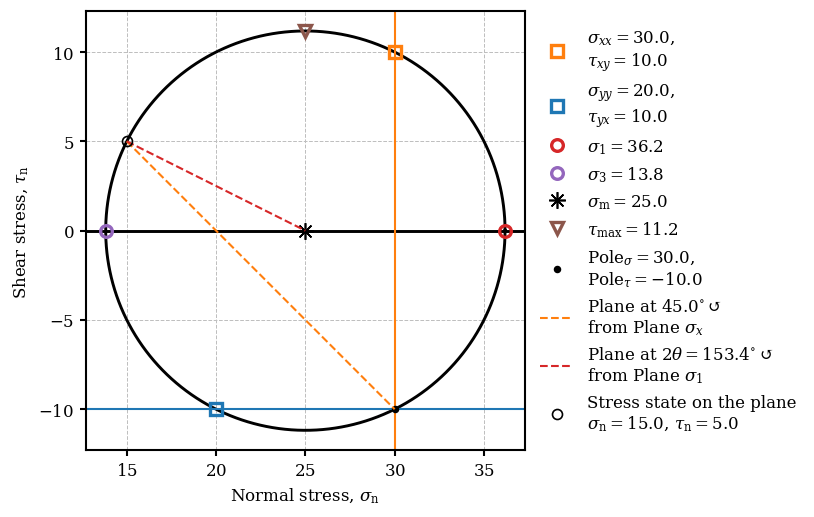

In [6]:
# plot_mohr_circle(𝜎_xx=30, 𝜎_yy=20, 𝜏_xy=10)
plot_mohr_circle(𝜎_xx=30, 𝜎_yy=20, 𝜏_xy=10, plot_pole=True, plot_plane=True, 𝛼=45)

In [7]:
s, l = {'description_width': '60px'}, wgt.Layout(width='400px')
s_env, l_env = {'description_width': '60px'}, wgt.Layout(width='190px')
controls = {
    'σ_xx': wgt.FloatSlider(value=30, min=-10, max=100, description="𝜎_xx", style=s, layout=l),
    'σ_yy': wgt.FloatSlider(value=20, min=-10, max=100, description="𝜎_yy", style=s, layout=l),
    'τ_xy': wgt.FloatSlider(value=10, min=-40, max=40, description="𝜏_xy", style=s, layout=l),
    'plot_pole': wgt.Checkbox(value=False, description="Plot pole?", style=s, layout=l),
    'plot_envelope': wgt.Checkbox(value=False, description="Plot envelope? → ", style=s_env, layout=l_env),
    'envelope': wgt.Text(value="'c': 5, '𝜙': 27", style=s_env, layout=l_env),
    'plot_plane': wgt.Checkbox(value=False, description="Plot a plane? → ", style=s_env, layout=wgt.Layout(width='180px')),
    'α': wgt.FloatSlider(value=45, min=0, max=180, step=0.2, description="α", style={'description_width': '10px'}, layout=wgt.Layout(width='220px')),
    'xlim': wgt.FloatRangeSlider(value=[10, 40], min=-50, max=100, step=.5, description='x-axis:', readout_format='.0f', style=s, layout=l),
    'ylim': wgt.FloatRangeSlider(value=[-15, 15], min=-100, max=100, step=.5, description='y-axis:', readout_format='.0f', style=s, layout=l),
    'static_fig': wgt.Checkbox(value=True, description='Non-vector image (improve widget performance)', disabled=False, style=s, layout=l)
}
c_all = list(controls.values())
c_env = [wgt.HBox(c_all[4:6])]
c_pln = [wgt.HBox(c_all[6:8])]
c = c_all[:4] + c_env + c_pln+ c_all[8:]
fig = wgt.interactive_output(plot_mohr_circle, controls)
wgt.HBox((wgt.VBox(c), fig), layout=wgt.Layout(align_items='center'))

## Herramienta 1

Estados de esfuerzo de una misma etapa en distintos puntos.

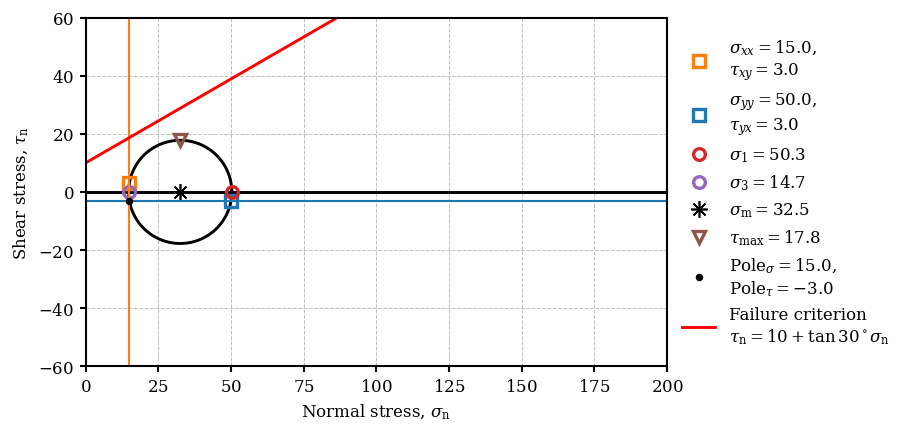

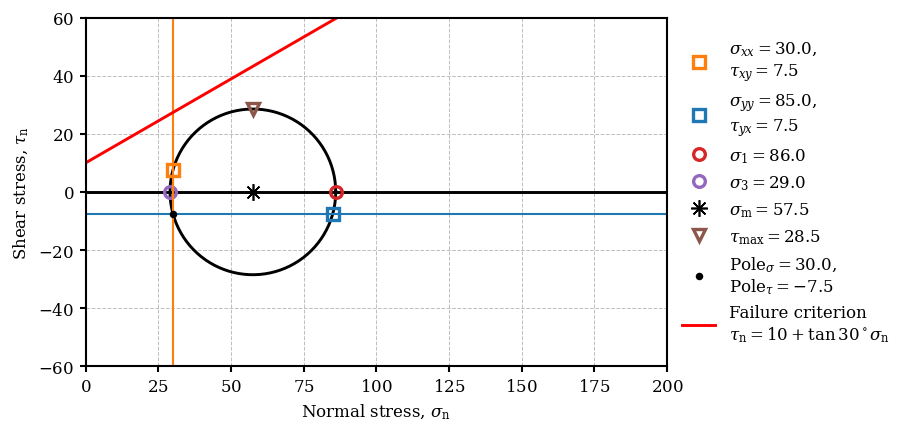

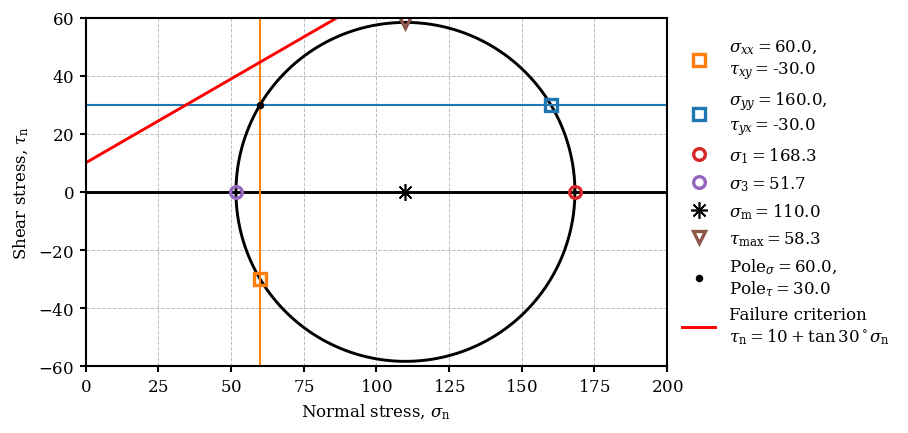

In [8]:
ptX_stg3 = plot_mohr_circle(𝜎_xx=15, 𝜎_yy=50, 𝜏_xy=3, envelope={'c': 10, '𝜙': 30}, plot_envelope=True, xlim=(00, 200), ylim=(-60, 60), plot_pole=True, figsize=[7.5, 3.5])
ptY_stg3 = plot_mohr_circle(𝜎_xx=30, 𝜎_yy=85, 𝜏_xy=7.5, envelope={'c': 10, '𝜙': 30}, plot_envelope=True, xlim=(00, 200), ylim=(-60, 60), plot_pole=True, figsize=[7.5, 3.5])
ptZ_stg3 = plot_mohr_circle(𝜎_xx=60, 𝜎_yy=160, 𝜏_xy=-30, envelope={'c': 10, '𝜙': 30}, plot_envelope=True, xlim=(00, 200), ylim=(-60, 60), plot_pole=True, figsize=[7.5, 3.5])

## Herramienta 2

Estados de esfuerzo de un punto durante distintas etapas.

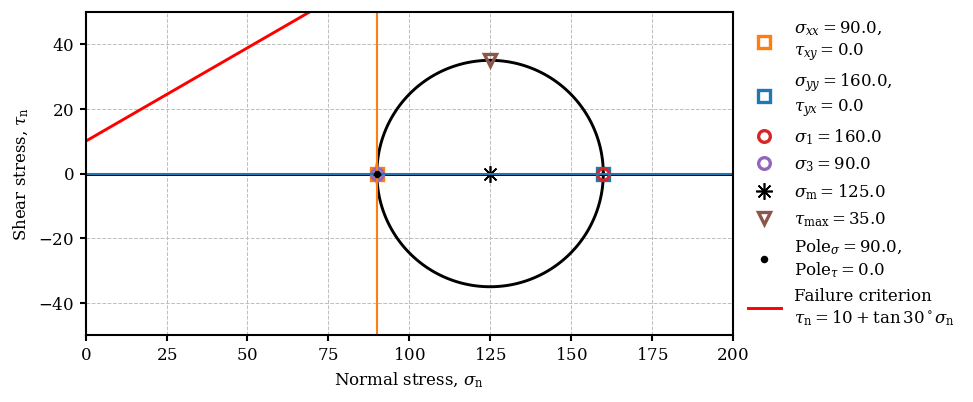

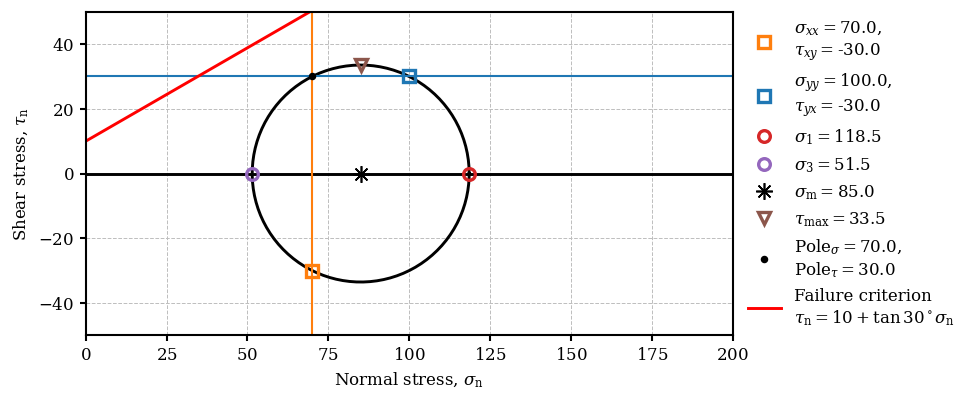

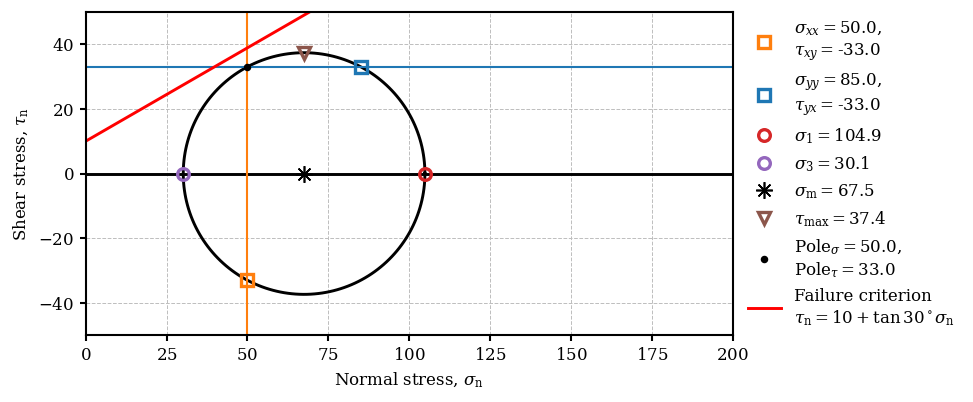

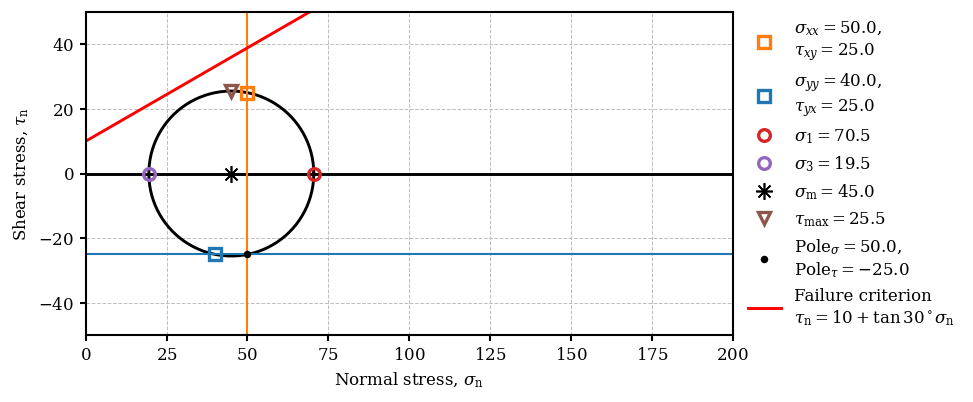

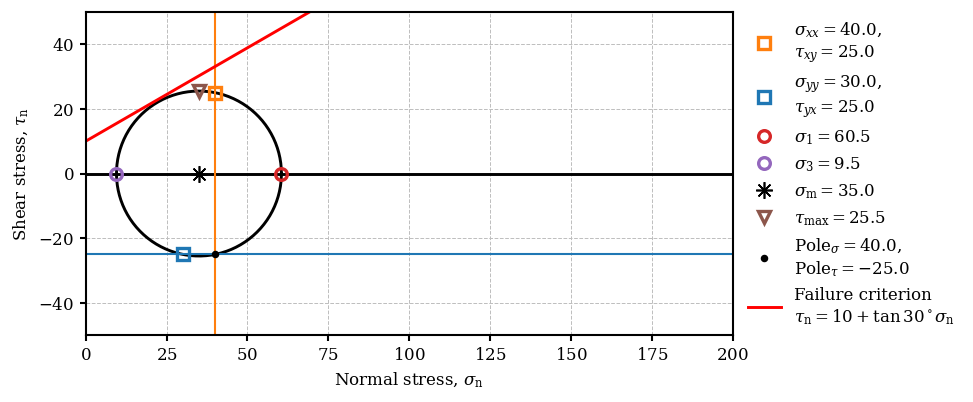

In [9]:
ptX_stg0 = plot_mohr_circle(𝜎_xx=90, 𝜎_yy=160, 𝜏_xy=0, envelope={'c': 10, '𝜙': 30}, plot_envelope=True, xlim=(0, 200), ylim=(-50, 50), plot_pole=True, figsize=[8,3.5])
ptX_stg1 = plot_mohr_circle(𝜎_xx=70, 𝜎_yy=100, 𝜏_xy=-30, envelope={'c': 10, '𝜙': 30}, plot_envelope=True, xlim=(0, 200), ylim=(-50, 50), plot_pole=True, figsize=[8,3.5])
ptX_stg2 = plot_mohr_circle(𝜎_xx=50, 𝜎_yy=85, 𝜏_xy=-33, envelope={'c': 10, '𝜙': 30}, plot_envelope=True, xlim=(0, 200), ylim=(-50, 50), plot_pole=True, figsize=[8,3.5])
ptX_stg3 = plot_mohr_circle(𝜎_xx=50, 𝜎_yy=40, 𝜏_xy=25, envelope={'c': 10, '𝜙': 30}, plot_envelope=True, xlim=(0, 200), ylim=(-50, 50), plot_pole=True, figsize=[8,3.5])
ptX_stg4 = plot_mohr_circle(𝜎_xx=40, 𝜎_yy=30, 𝜏_xy=25, envelope={'c': 10, '𝜙': 30}, plot_envelope=True, xlim=(0, 200), ylim=(-50, 50), plot_pole=True, figsize=[8,3.5])

## Herramienta 3

Trayectoria de esfuerzos

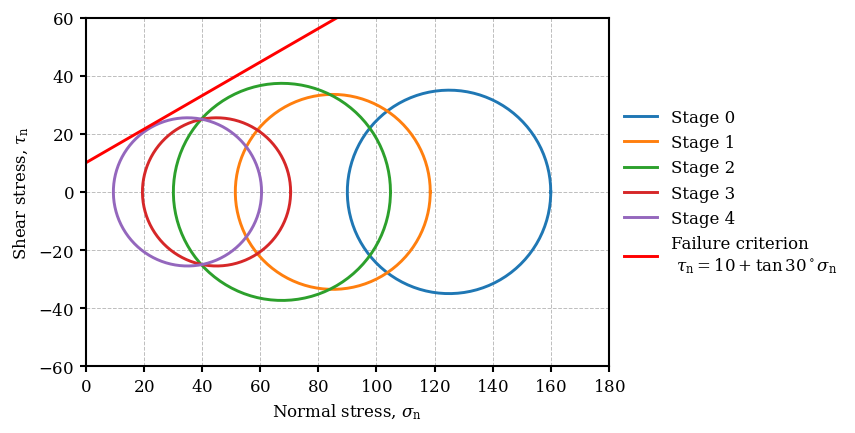

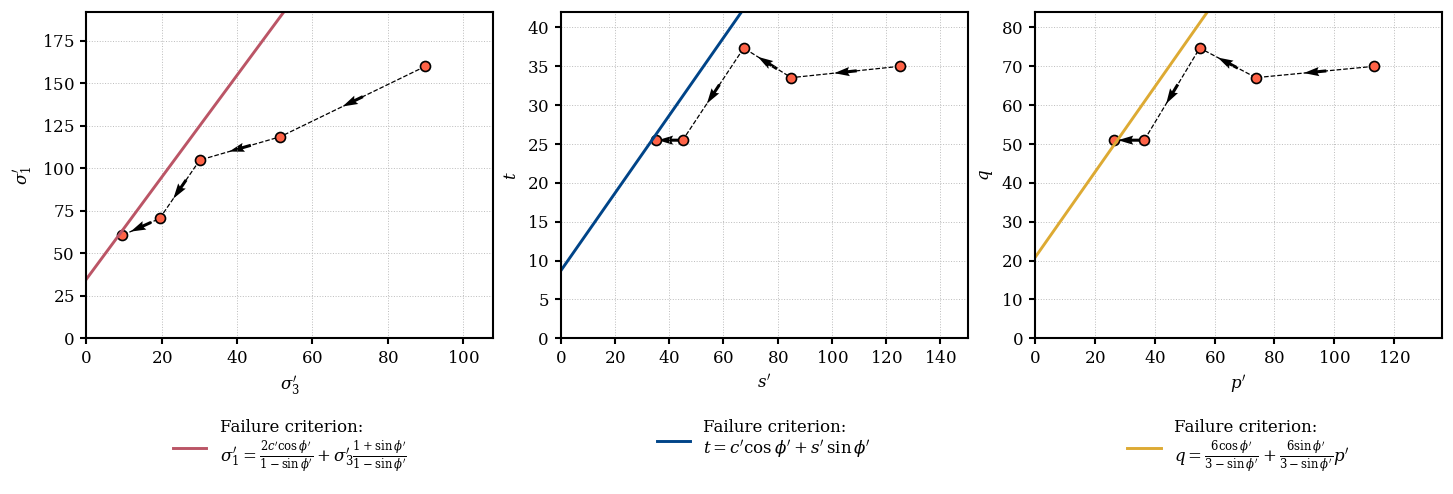

In [10]:
ptX_stgs = (ptX_stg0, ptX_stg1, ptX_stg2, ptX_stg3, ptX_stg4)
# All Mohr Circles in one plot
plot_all_mohr_circles(ptX_stgs, envelope={'c': 10, '𝜙': 30}, xlim=(0, 180), ylim=(-60, 60), figsize=[8,3.5])
# Stress paths in trhee spaces
plot_stress_path(ptX_stgs, envelope={'c': 10, '𝜙': 30}, figsize=[12, 4])
# plot_stress_path(ptX_stgs, envelope={'c': 10, '𝜙': 30}, figsize=[12, 4], xlim=(-10, 100), ylim=(-10, 200))